# Learning goals
After today's lesson you should be able to:
- Learn how to perform standard regression analysis using `statsmodels`
- Learn how to conduct Geographically Weighted Regression (GWR) using `PySAL`

statsmodels is designed for general-purpose statistical modeling (like OLS, time series, and GLMs), while PySAL focuses on spatial data analysis, offering tools for spatial regression, GWR, and spatial diagnostics.

## 1. Regression Analysis using `statsmodels`

#### Data Preparation

In this exercise, we will return back to use the data set of Beijing resale home transactions (bjsample1000.csv). The variables are:
- DTUP: Deflated transacted unit price (RMB per square meter)
- SDIST: distance to the nearest subway station (meter)
- FAREA: floor area (square meter)
- BED: number of bedrooms
- BATH: number of bathrooms
- LIV: number of living rooms
- DIST_CBD: distance to CBD (meter)
- DIST_CENTER: distance to center (meter)
- BN500: number of bus stops in 500 meters
- WGSLON: longitude
- WGSLAT: latitude

### 1.1 Simple regression model

Let us first recap - how to conduct a simple OLS regression using `statsmodels` to examine the influential factors of home sale prices. 

Note: The *statsmodels* comes with Anaconda distribution. If you did not install Python with Anaconda, you can install statsmodels using pip or conda.

In [60]:
import pandas as pd            # import Pandas library
import statsmodels.api as sm   # import statsmodels library

In [61]:
# load data 'bjsample1.csv'
df = pd.read_csv('bjsample1000geo.csv')

#### Regression with multiple variables

In [62]:
# create a variable in the dataframe named "const" with all values equal to 1
df['CONST'] = 1

# define dependent variable y
y = df['DTUP']

# Model with constant, subway, and all structural variables
X = df[['CONST', 'SDIST','FAREA', 'BED', 'BATH', 'LIV']] 

reg_ols = sm.OLS(y, X)

result = reg_ols.fit() 

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                   DTUP   R-squared:                       0.144
Model:                            OLS   Adj. R-squared:                  0.139
Method:                 Least Squares   F-statistic:                     33.31
Date:                Tue, 08 Apr 2025   Prob (F-statistic):           1.69e-31
Time:                        09:44:16   Log-Likelihood:                -11010.
No. Observations:                1000   AIC:                         2.203e+04
Df Residuals:                     994   BIC:                         2.206e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
CONST       4.653e+04   1701.289     27.350      0.0

#### Try different sets of independent variables in a loop

We want to test the estimation performance by using different sets of independent variables. We could run them in a loop by changing the definition of X. Note that we employ a very useful function eval() to convert a string name into a variable.

In [9]:
ind_var1 = ['CONST', 'SDIST']
ind_var2 = ['CONST', 'SDIST', 'FAREA', 'BED', 'BATH', 'LIV']
ind_var3 = ['CONST', 'SDIST', 'FAREA', 'BED', 'BATH', 'LIV', 'BN500']
ind_var4 = ['CONST', 'SDIST', 'FAREA', 'BED', 'BATH', 'LIV', 'BN500', 'DIST_CBD', 'DIST_CENTER']

In [63]:

for m in range(1,5):  # generate value from 1 to 4

    # define dependent variable y
    y = df['DTUP']

    # define independent variable X 
    # eval() function is used to loop over variable names
    X = df[eval('ind_var' + str(m))]       
    

    # define regression model 
    reg_ols = sm.OLS(y, X)

    # run the regression
    results_ols = reg_ols.fit()

    # show the results
    print(results_ols.summary())


                            OLS Regression Results                            
Dep. Variable:                   DTUP   R-squared:                       0.110
Model:                            OLS   Adj. R-squared:                  0.109
Method:                 Least Squares   F-statistic:                     123.2
Date:                Tue, 08 Apr 2025   Prob (F-statistic):           4.44e-27
Time:                        09:44:54   Log-Likelihood:                -11030.
No. Observations:                1000   AIC:                         2.206e+04
Df Residuals:                     998   BIC:                         2.207e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
CONST       4.463e+04    657.088     67.920      0.0

### 1.2 Combine results from different models

To compare the results of all four models, we want to summarize the estimates in one table. We could employ `summary_col` function to do this. Let's test this function using the first two models.

First, let's run the first two models and save their results with different names (result_1 and result_2).

In [64]:
# Model 1
X = df[['CONST', 'SDIST']] 
reg_ols = sm.OLS(y, X)
result_1 = reg_ols.fit()   # the name of the model 1's result is result_1
print(result_1.summary())

# Model 2
X = df[['CONST', 'SDIST','FAREA', 'BED', 'BATH', 'LIV']] 
reg_ols = sm.OLS(y, X)
result_2 = reg_ols.fit()   # the name of the model 1's result is result_1
print(result_2.summary())

                            OLS Regression Results                            
Dep. Variable:                   DTUP   R-squared:                       0.110
Model:                            OLS   Adj. R-squared:                  0.109
Method:                 Least Squares   F-statistic:                     123.2
Date:                Tue, 08 Apr 2025   Prob (F-statistic):           4.44e-27
Time:                        09:45:24   Log-Likelihood:                -11030.
No. Observations:                1000   AIC:                         2.206e+04
Df Residuals:                     998   BIC:                         2.207e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
CONST       4.463e+04    657.088     67.920      0.0

Then, we use `summary_col` to combine the two results.

In [12]:
# import summary_col
from statsmodels.iolib.summary2 import summary_col

In [65]:
result_all = summary_col([result_1, result_2])   
# Note that the results are listed in a list [result_1, results_2]
print(result_all)


                 DTUP I     DTUP II  
-------------------------------------
CONST          44629.5038 46529.8332 
               (657.0879) (1701.2892)
SDIST          -4.7254    -4.5947    
               (0.4257)   (0.4195)   
FAREA                     -151.5706  
                          (27.8091)  
BED                       778.0613   
                          (907.3471) 
BATH                      6328.6295  
                          (1720.9425)
LIV                       1367.0063  
                          (1134.5960)
R-squared      0.1099     0.1435     
R-squared Adj. 0.1090     0.1392     
Standard errors in parentheses.


This *summary_col* function allows to add significant stars and other statistics, such as number of observations and adjusted R-squared. Check here for all statistics allowed https://www.statsmodels.org/devel/generated/statsmodels.regression.linear_model.RegressionResults.html

In [67]:
result_all = summary_col(
     [result_1, result_2],
    
     # round the estimates to 2 decimal places
     float_format="%.2f",         
                         
     # add significant stars
     stars=True,      
    
     info_dict={'N':lambda x: "{0:d}".format(int(x.nobs))} # add number of observations
                #'R2_Adj':lambda x: "{:.2f}".format(x.rsquared_adj)} # add adjusted R-squared
)
print(result_all)


                  DTUP I     DTUP II  
--------------------------------------
CONST          44629.50*** 46529.83***
               (657.09)    (1701.29)  
SDIST          -4.73***    -4.59***   
               (0.43)      (0.42)     
FAREA                      -151.57*** 
                           (27.81)    
BED                        778.06     
                           (907.35)   
BATH                       6328.63*** 
                           (1720.94)  
LIV                        1367.01    
                           (1134.60)  
R-squared      0.11        0.14       
R-squared Adj. 0.11        0.14       
N              1000        1000       
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


### 1.3 Combine results in a loop

Now, we can combine all the results from the four models in a loop. Basically, we combine the results in a list and then apply summary_col on the list.

In [68]:
ind_var1 = ['CONST', 'SDIST']
ind_var2 = ['CONST', 'SDIST', 'FAREA', 'BED', 'BATH', 'LIV']
ind_var3 = ['CONST', 'SDIST', 'FAREA', 'BED', 'BATH', 'LIV', 'BN500']
ind_var4 = ['CONST', 'SDIST', 'FAREA', 'BED', 'BATH', 'LIV', 'BN500', 'DIST_CBD', 'DIST_CENTER']

# define a list save results
result_list = []

for m in range(1,5):  # generate value from 1 to 4

    # define dependent variable y
    y = df['DTUP']

    # define independent variable X 
    X = df[eval('ind_var' + str(m))]       # eval() function is used to loop over variable names

    # define regression model 
    reg_ols = sm.OLS(y, X)

    # run the regression
    results_ols = reg_ols.fit()
    
    # append result to the result list
    result_list.append(results_ols)

In [69]:
result_all = summary_col(result_list,     # use result_list here
                         float_format="%.2f", 
                         stars=True, 
                         info_dict={'N':lambda x: "{0:d}".format(int(x.nobs)),
                                    'R2_Adj':lambda x: "{:.2f}".format(x.rsquared_adj)},
                         regressor_order = ['CONST', 'SDIST', 'FAREA', 'BED', 'BATH', 'LIV', 'BN500', 'DIST_CBD', 'DIST_CENTER']  # set the display order of the regressors
                        )
print(result_all)


                  DTUP I     DTUP II     DTUP III   DTUP IIII 
--------------------------------------------------------------
CONST          44629.50*** 46529.83*** 48271.78*** 56033.37***
               (657.09)    (1701.29)   (1876.16)   (1693.57)  
SDIST          -4.73***    -4.59***    -4.79***    -1.86***   
               (0.43)      (0.42)      (0.43)      (0.42)     
FAREA                      -151.57***  -155.54***  -103.61*** 
                           (27.81)     (27.82)     (24.37)    
BED                        778.06      940.82      156.38     
                           (907.35)    (908.70)    (798.19)   
BATH                       6328.63***  6258.34***  4551.20*** 
                           (1720.94)   (1717.99)   (1496.02)  
LIV                        1367.01     1315.91     1880.38*   
                           (1134.60)   (1132.69)   (984.59)   
BN500                                  -59.17**    -25.96     
                                       (27.10)     (23

## 2. Spatial regression (GWR) analysis using `Pysal` 

Above, we used OLS to run a regression. As you can see, the coefficient for each variable is fixed—meaning the effect of any given variable on housing prices is assumed to be the same across all locations in Beijing. However, this assumption is rarely realistic. In practice, the impact of a variable on housing prices often varies by location, a phenomenon known as *spatial heterogeneity*. To account for this, we can use the Geographically Weighted Regression (GWR) model with the PySAL library to estimate how the influence of each variable changes across space.

It’s important to note that PySAL also supports another major type of spatial modeling: **spatial autoregressive regressions**, which are what we introduced before the spring break - we used PySAL to run spatial error, spatial lag, and SLX models. These models incorporate the effects of neighboring areas into the regression, but unlike GWR, they still produce global coefficients, similar to those from OLS. Here, **we will demo the GWR regression. For spatial autoregressive regressions (spatial error, spatial lag, SLX, etc), refer to Lab 10.**

This time, the data contain geographic coordinates. Let's first convert the data into a geodataframe.

In [70]:
import numpy as np
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
%matplotlib inline

In [71]:
# load data
df = pd.read_csv('bjsample1000geo.csv')

In [73]:
# Create GeoDataFrame directly from coordinate columns
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['WGSLON'], df['WGSLAT']),
    crs='EPSG:4326'
)

Here, we provide an example of implementing GWR in Python from data preparation to result plots. You can refer to here for more examples of GW` and MGWR (https://github.com/pysal/mgwr/tree/master/notebooks).

In [76]:
# install library "mgwr" and import 
from mgwr.gwr import GWR
# automatically find the optimal bandwidth
from mgwr.sel_bw import Sel_BW

In [78]:
g_X = gdf[['SDIST', 'FAREA', 'BED', 'BATH', 'LIV', 'DIST_CBD']].values
g_X.shape

(1000, 6)

In [79]:
# prepare inputs
g_y = gdf['DTUP'].values.reshape((-1,1))
g_X = gdf[['SDIST', 'FAREA', 'BED', 'BATH', 'LIV', 'DIST_CBD']].values
u = gdf['WGSLON']
v = gdf['WGSLAT']
g_coords = list(zip(u,v))

In [80]:
# standardization - 
# Standardize the predictors and target - all variables are on the same scale.
g_X = (g_X - g_X.mean(axis=0)) / g_X.std(axis=0) 
# axis = 0: computes mean and SD of each column
g_y = (g_y - g_y.mean(axis=0)) / g_y.std(axis=0)

In [81]:
%%time 

# calibrate GWR model
# Initialize bandwidth selector
gwr_selector = Sel_BW(g_coords, g_y, g_X)

# Search for optimal bandwidth - minimum of 2 neighbors
gwr_bw = gwr_selector.search(bw_min=2)

print(gwr_bw) # 69： each local regression considers the 69 nearest neighbors

# Fit the GWR model
gwr_results = GWR(g_coords, g_y, g_X, gwr_bw).fit()

69.0
CPU times: total: 6.72 s
Wall time: 28.3 s


In [82]:
# display result
gwr_results.summary()

Model type                                                         Gaussian
Number of observations:                                                1000
Number of covariates:                                                     7

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            748.941
Log-likelihood:                                                   -1274.391
AIC:                                                               2562.783
AICc:                                                              2564.928
BIC:                                                              -6110.460
R2:                                                                   0.251
Adj. R2:                                                              0.247

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

Next, let us (1) extract the local GWR coefficients for each explanatory variable and stores them in the gdf for mapping, and (2) retrieve t-values adjusted for multiple testing to assess statistical significance. 

Here, `gwr_results.params` is a 2D NumPy array where: Each row corresponds to a spatial location (i.e. an observation or point in your dataset). Each column corresponds to a regression coefficient (i.e. one of your independent variables).

In [83]:
#Prepare GWR results for mapping
x_list = ['SDIST', 'FAREA', 'BED', 'BATH', 'LIV', 'DIST_CBD']

#Add GWR parameters to GeoDataframe
for v in range(len(x_list)):
    gdf['gwr_' + x_list[v]] = gwr_results.params[:, v]

#Obtain t-vals filtered based on multiple testing correction
gwr_filtered_t = gwr_results.filter_tvals()

Okay, next, the following chunk of code creates a 2×3 grid of maps to visualize the spatial distribution of GWR local coefficients for each explanatory variable. Each subplot shows how the effect of one variable (e.g., SDIST, FAREA, etc.) on the dependent variable varies across geographic space.

Note: `ax = ax[v // 3, v % 3]` will iterate through all 6 subplots in a 2x3 grid, moving left-to-right, top-to-bottom.

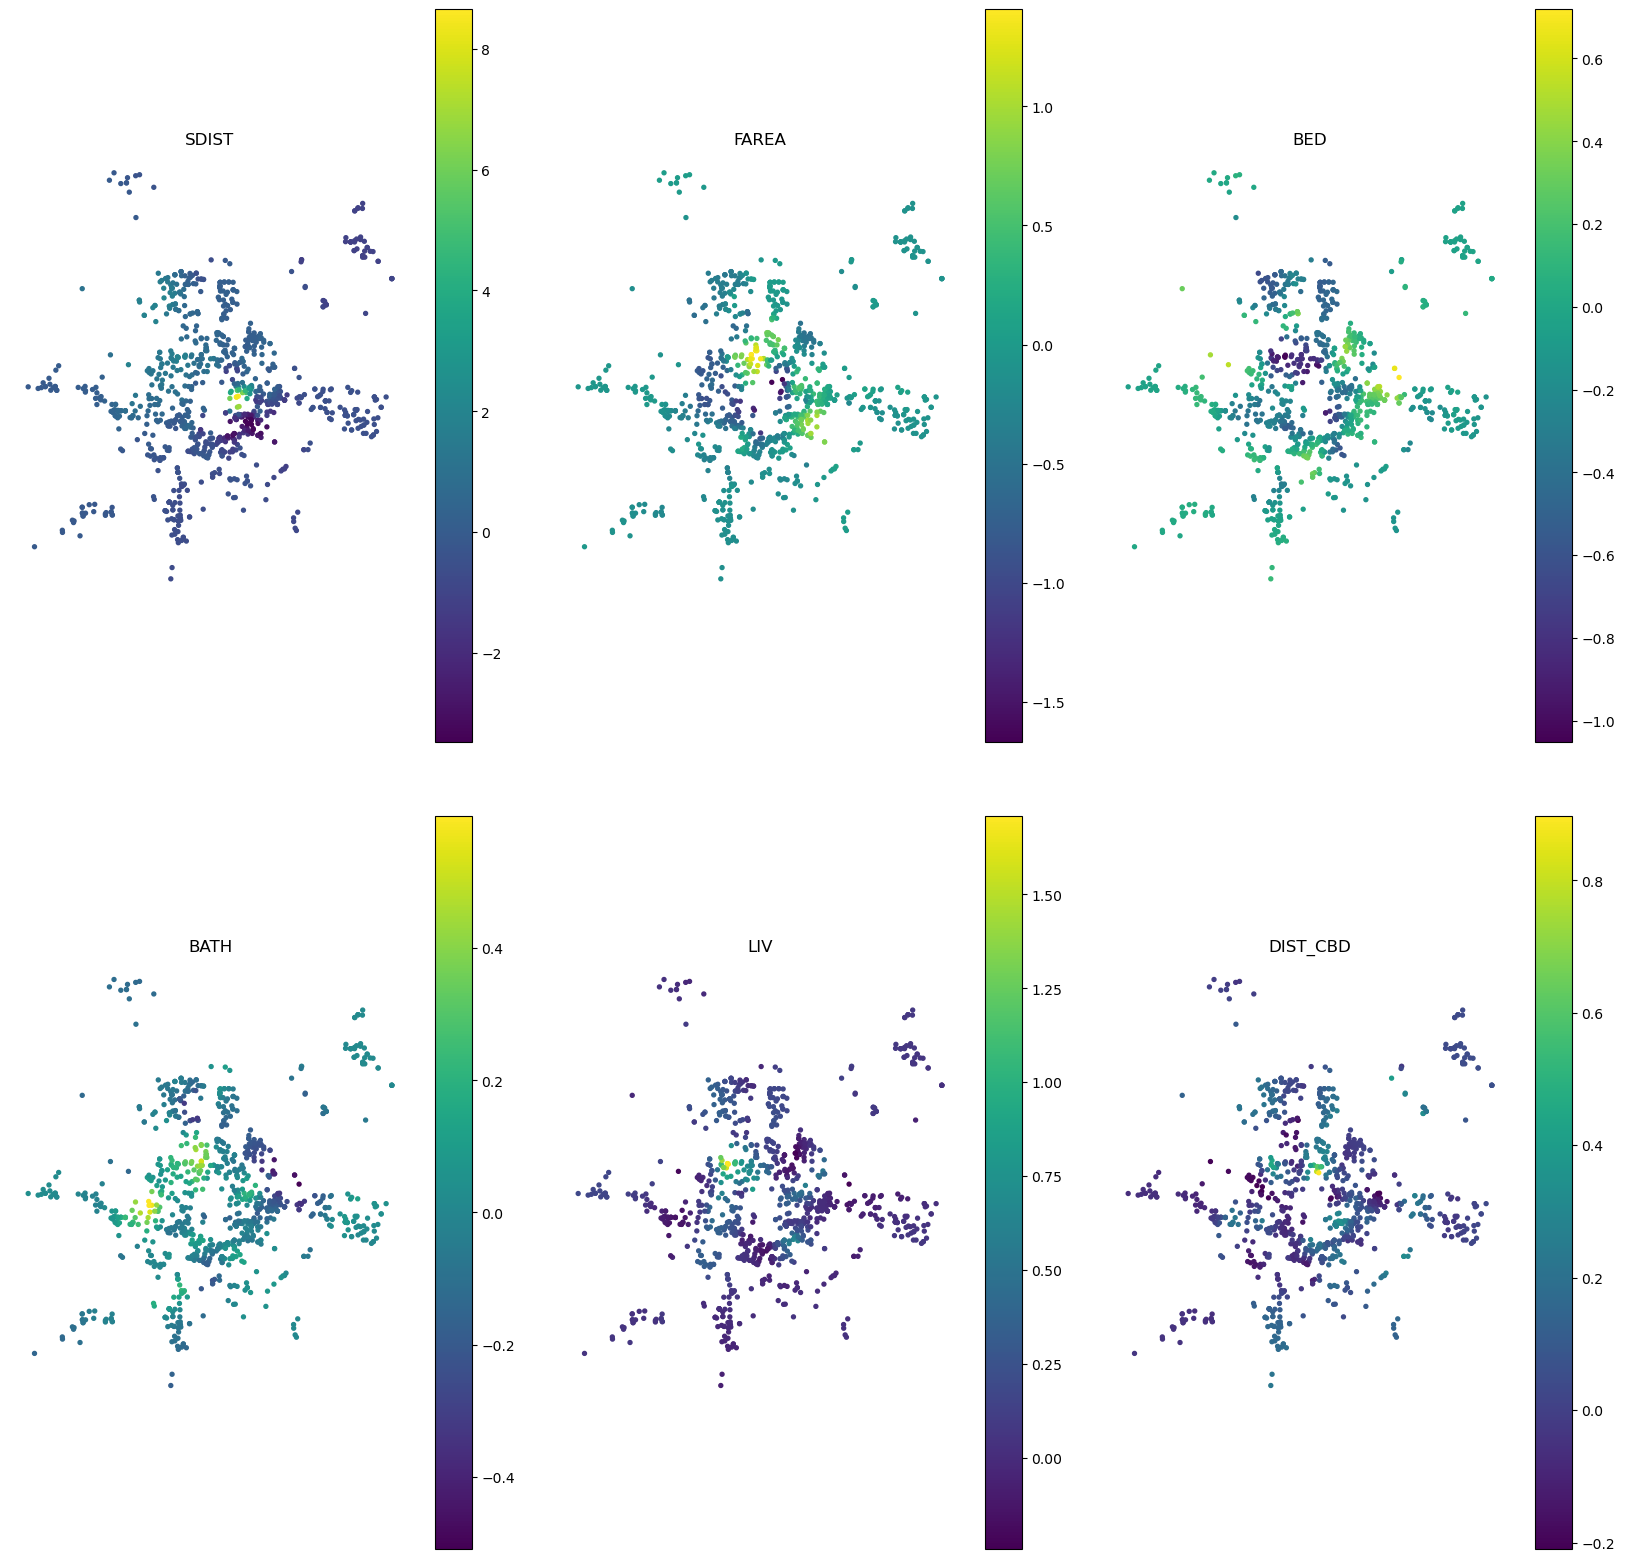

In [85]:
%matplotlib inline
import matplotlib.pyplot as plt

x_list = ['SDIST', 'FAREA', 'BED', 'BATH', 'LIV', 'DIST_CBD']
fig, ax = plt.subplots(2, 3, figsize = (20, 20))

for v in range(len(x_list)):
    # % returns the remainder
    # // Integer (floor) division
    gdf.plot(ax = ax[v//3, v%3],
             column = 'gwr_' + x_list[v],
             markersize = 8,
             legend = True)
    
    ax[v//3, v%3].set_title(x_list[v])
    ax[v//3, v%3].axis('off')
    
plt.subplots_adjust(left=0.1, wspace = 0.1, hspace = 0.1)

Note that each observation has not only a coefficient estimate but also a corresponding t-value, which allows us to assess its statistical significance. 

The code chunk below filters out statistically insignificant observations and keeps only those that are significant.

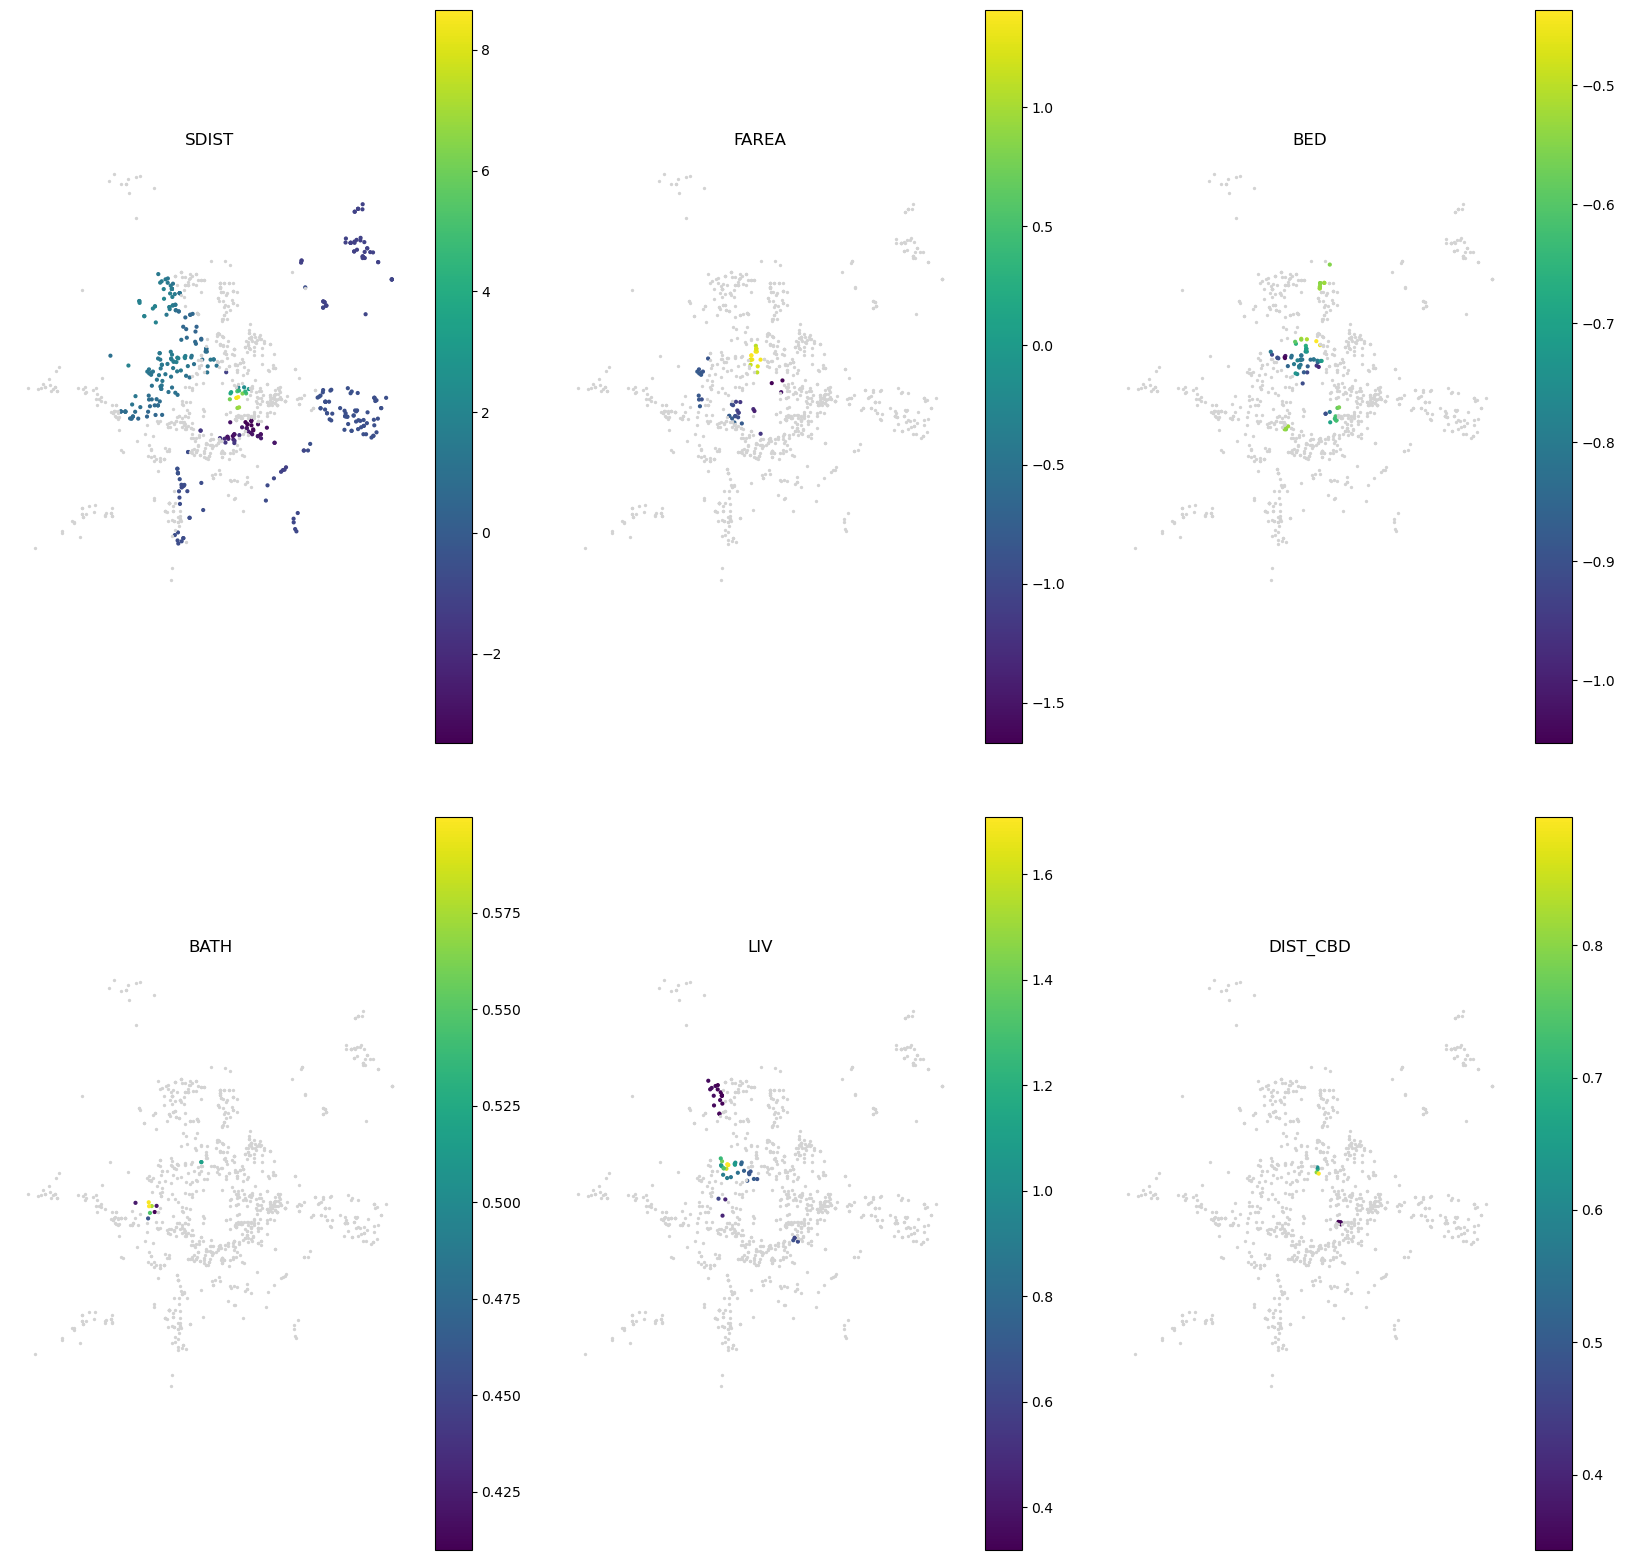

In [57]:
# plot with consideration of local inference (plot insignificant estimates differently)

x_list = ['SDIST', 'FAREA', 'BED', 'BATH', 'LIV', 'DIST_CBD']

fig, ax = plt.subplots(2, 3, figsize = (20, 20))

for v in range(len(x_list)):

    gdf[gwr_filtered_t[:,v] != 0].plot(ax = ax[v//3, v%3],
             column = 'gwr_' + x_list[v],
             markersize = 4,
             legend = True)
    
    gdf[gwr_filtered_t[:,v] == 0].plot(ax = ax[v//3, v%3], 
                                       color='lightgrey',
                                       markersize = 2
                                       )
    
    ax[v//3, v%3].set_title(x_list[v])
    ax[v//3, v%3].axis('off')
    
plt.subplots_adjust(left=0.1, wspace = 0.1, hspace = 0.1)